In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


Ensure to run file "RF_Initial_Feature_Engineering.py" in path 2b_feature_engineering prior to this notebook to populate featureset.

Now, I want to try to use SMOTE on training data to deal with class imbalance 

In [3]:
df = pd.read_parquet("../../../1_download_data/model_ready/flights_model_ready.parquet")
df.head()


,FlightDate,Airline,Origin,Dest,CRSDepTime,CRSElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,year,target,date,dep_hour,tmpf,vsby,sknt,p01i,relh,gust,DayOfWeek_num,month_sin,month_cos,dow_sin,dow_cos,Distance_std,tmpf_std,vsby_std,sknt_std,relh_std,gust_std,distance_origin_norm,has_precip,is_holiday,prev_day_failure_origin,is_morning_peak,is_evening_peak
0,2018-01-03,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,3,Wednesday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,Delayed,2018-01-03,10,27.0,10.0,6.000000,0.0,40.42,0.0,2,0.5,0.866025,0.974928,-0.222521,-1.181369,-1.795908,0.372,-0.268741,-1.032586,-0.532803,-506.21629,0,0,1,0,0
1,2018-01-04,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,4,Thursday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-04,10,24.1,10.0,14.166667,0.0,54.36,21.0,3,0.5,0.866025,0.433884,-0.900969,-1.181369,-1.949265,0.372,1.558113,-0.405039,1.744748,-506.21629,0,0,1,0,0
2,2018-01-05,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,5,Friday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8877A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-05,10,17.1,10.0,12.153846,0.0,55.51,0.0,4,0.5,0.866025,-0.433884,-0.900969,-1.181369,-2.319438,0.372,1.107853,-0.353268,-0.532803,-506.21629,0,0,1,0,0
3,2018-01-06,Endeavor Air Inc.,ATL,ABY,1037,59.0,145.0,2018,1,1,6,Saturday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8970D,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1136,1100-1159,1,2018,On time,2018-01-06,10,21.9,10.0,6.846154,0.0,57.02,0.0,5,0.5,0.866025,-0.974928,-0.222521,-1.181369,-2.065605,0.372,-0.079459,-0.285291,-0.532803,-506.21629,0,0,1,0,0
4,2018-01-07,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,7,Sunday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8980A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-07,10,21.9,10.0,7.384615,0.0,54.75,0.0,6,0.5,0.866025,-0.781831,0.623490,-1.181369,-2.065605,0.372,0.040993,-0.387482,-0.532803,-506.21629,0,0,1,0,0


In [5]:
import sys
from pathlib import Path

# Get the root project directory (two levels up from the notebook)
project_root = Path.cwd().parents[1]  # notebooks/ → project root
scripts_path = project_root / "scripts"
sys.path.append(str(scripts_path))

In [6]:
# X_train, X_test, y_train, y_test = sample_and_split(
#     df,
#     total_sample=500_000,
#     max_origin_frac=0.05,
#     max_region_frac=0.3,
#     test_size=0.2,
#     output_dir="../../data/model_ready/sampled_splits",
#     random_state=42
# )

In [8]:
train_df = pd.read_parquet("../../../1_download_data/model_ready/sampled_splits/train.parquet")
test_df = pd.read_parquet("../../../1_download_data/model_ready/sampled_splits/test.parquet")
print(f"train shape: {train_df.shape}")
print(f"test shape: {test_df.shape}")

X_train = train_df.drop(columns = "target", axis =1)
y_train = train_df.target


X_test = test_df.drop(columns = "target", axis =1)
y_test = test_df.target

train shape: (179519, 71)
test shape: (44880, 71)


In [9]:
train_df.target.value_counts(normalize=True)

target
On time      0.611790
Delayed      0.352837
Cancelled    0.035372
Name: proportion, dtype: float64

In [13]:
from imblearn.over_sampling import SMOTE

In [14]:
# Smote only takes numerical values

In [15]:

smote = SMOTE(random_state=42)

## Random Forest Model Smote (only numerical)

In [16]:
FEATURES = ["Quarter", "Month", "DayofMonth", "dep_hour", 
 "Distance",
    "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
     #"DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
]

TARGET = "target"


In [17]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split categorical vs numerical
# categorical_features = [
#     "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
# ]

numeric_features = [
    "Quarter", "Month", "DayofMonth", "dep_hour",
    "Distance", "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
       # ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)



In [18]:
rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)


In [19]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf_model)
])


In [20]:
# Convert categorical columns to string (needed for OneHotEncoder)
# for col in categorical_features:
#     X_train[col] = X_train[col].astype(str)
#     val_df[col]   = val_df[col].astype(str)
#     X_test[col]  = X_test[col].astype(str)

# # Fill numeric NaNs with 0
for col in numeric_features:
    X_train[col] = X_train[col].fillna(0)
    X_test[col]  = X_test[col].fillna(0)

# Optional: fill categorical NaNs with "missing"
# for col in categorical_features:
#     X_train[col] = X_train[col].fillna("missing")
#     val_df[col]   = val_df[col].fillna("missing")
#     X_test[col]  = X_test[col].fillna("missing")

In [21]:
X_train.head()

,FlightDate,Airline,Origin,Dest,CRSDepTime,CRSElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,year,date,dep_hour,tmpf,vsby,sknt,p01i,relh,gust,DayOfWeek_num,month_sin,month_cos,dow_sin,dow_cos,Distance_std,tmpf_std,vsby_std,sknt_std,relh_std,gust_std,distance_origin_norm,has_precip,is_holiday,prev_day_failure_origin,is_morning_peak,is_evening_peak,month,OriginRegion
0,2022-06-07,United Air Lines Inc.,LGA,IAH,600,223.0,1416.0,2022,2,6,7,Tuesday,UA,UA,19977,UA,2629,UA,19977,UA,N417UA,2629,12953,1295304,31703,"New York, NY",NY,36,New York,22,12266,1226603,31453,"Houston, TX",TX,48,Texas,74,0600-0659,843,0800-0859,6,2022,2022-06-07,6,67.0,10.000000,7.384615,0.0,41.87,0.0,1,1.224647e-16,-1.000000,0.781831,0.623490,0.911156,0.319365,0.37200,0.040993,-0.967310,-0.532803,682.108396,0,0,1,1,0,2022-06,Northeast
1,2021-12-11,Spirit Air Lines,EWR,FLL,510,188.0,1065.0,2021,4,12,11,Saturday,NK,NK,20416,NK,521,NK,20416,NK,N661NK,521,11618,1161802,31703,"Newark, NJ",NJ,34,New Jersey,21,11697,1169706,32467,"Fort Lauderdale, FL",FL,12,Florida,33,0001-0559,818,0800-0859,5,2021,2021-12-11,5,47.0,10.000000,3.538462,0.0,63.33,0.0,5,-2.449294e-16,1.000000,-0.974928,-0.222521,0.333284,-0.738272,0.37200,-0.819378,-0.001230,-0.532803,64.651711,0,0,1,0,0,2021-12,Northeast
2,2021-08-20,Southwest Airlines Co.,LAS,PDX,745,130.0,763.0,2021,3,8,20,Friday,WN,WN,19393,WN,1573,WN,19393,WN,N223WN,1573,12889,1288903,32211,"Las Vegas, NV",NV,32,Nevada,85,14057,1405702,34057,"Portland, OR",OR,41,Oregon,92,0700-0759,955,0900-0959,4,2021,2021-08-20,7,82.0,8.615385,1.846154,0.0,18.54,0.0,4,-8.660254e-01,-0.500000,-0.433884,-0.900969,-0.163918,1.112592,-0.39694,-1.197941,-2.017574,-0.532803,-215.333605,0,0,1,1,0,2021-08,West
3,2018-08-06,Republic Airlines,ORD,MDT,745,113.0,594.0,2018,3,8,6,Monday,UA,UA_CODESHARE,19977,UA,3753,YX,20452,YX,N633RW,3753,13930,1393006,30977,"Chicago, IL",IL,17,Illinois,41,13230,1323002,32070,"Harrisburg, PA",PA,42,Pennsylvania,23,0700-0759,1038,1000-1059,3,2018,2018-08-06,7,76.0,10.000000,4.692308,0.0,73.68,0.0,0,-8.660254e-01,-0.500000,0.000000,1.000000,-0.442153,0.795301,0.37200,-0.561267,0.464704,-0.532803,-113.482071,0,0,1,1,0,2018-08,Midwest
4,2022-07-29,United Air Lines Inc.,EWR,FLL,805,189.0,1065.0,2022,3,7,29,Friday,UA,UA,19977,UA,1613,UA,19977,UA,None,1613,11618,1161802,31703,"Newark, NJ",NJ,34,New Jersey,21,11697,1169706,32467,"Fort Lauderdale, FL",FL,12,Florida,33,0800-0859,1114,1100-1159,5,2022,2022-07-29,8,75.0,10.000000,6.846154,0.0,78.86,0.0,4,-5.000000e-01,-0.866025,-0.433884,-0.900969,0.333284,0.742419,0.37200,-0.079459,0.697896,-0.532803,64.651711,0,0,1,1,0,2022-07,Northeast


In [22]:
X_train_smote, y_train_smote = smote.fit_resample(X_train[FEATURES], y_train)


In [23]:
pipeline.fit(X_train_smote[FEATURES], y_train_smote)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Quarter', 'Month',
                                                   'DayofMonth', 'dep_hour',
                                                   'Distance', 'tmpf', 'vsby',
                                                   'sknt', 'p01i', 'relh',
                                                   'gust'])])),
                ('rf',
                 RandomForestClassifier(max_depth=15, n_estimators=80,
                                        n_jobs=-1, random_state=42))])

The test set stays the same when using SMOTE.

In [24]:
# Predictions
y_pred = pipeline.predict(X_test[FEATURES])

# Metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(y_test, y_pred, normalize="true")
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)
print("\nNormalized Confusion Matrix:\n")
print(cm_df)



Classification Report:

              precision    recall  f1-score   support

   Cancelled      0.112     0.359     0.170      1587
     Delayed      0.475     0.441     0.458     15836
     On time      0.706     0.645     0.674     27457

    accuracy                          0.563     44880
   macro avg      0.431     0.482     0.434     44880
weighted avg      0.604     0.563     0.580     44880


Normalized Confusion Matrix:

           Cancelled   Delayed   On time
Cancelled   0.358538  0.312539  0.328922
Delayed     0.126610  0.441210  0.432180
On time     0.091998  0.262847  0.645154


Test Accuracy: 0.563

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled        569      496      522
Delayed         2005     6987     6844
On time         2526     7217    17714

Confusion Matrix (normalized):
           Cancelled   Delayed   On time
Cancelled   0.358538  0.312539  0.328922
Delayed     0.126610  0.441210  0.432180
On time     0.091998  0.262847  0.645154


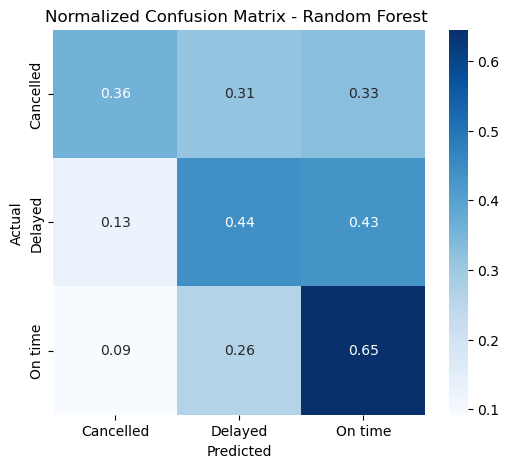


Classification Report:
              precision    recall  f1-score   support

   Cancelled      0.112     0.359     0.170      1587
     Delayed      0.475     0.441     0.458     15836
     On time      0.706     0.645     0.674     27457

    accuracy                          0.563     44880
   macro avg      0.431     0.482     0.434     44880
weighted avg      0.604     0.563     0.580     44880



In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Make predictions on test set
# -----------------------------
y_pred = pipeline.predict(X_test[FEATURES])
y_true = y_test

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (normalized):")
print(cm_norm_df)

# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest ")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Step 5: Optional detailed classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))


Applying SMOTE to balance the dataset resulted in improved detection of minority classes. Recall for cancellations increased to 34%, and nearly 45% of delays were correctly identified. The improvement comes at the expense of precision and on-time flight recall, which dropped to 64%. 

This illustrates the expected tradeoff when oversampling rare events: the classifier becomes more sensitive to disruptions but also more prone to false alarms. Overall, the model demonstrates that synthetic oversampling can help address class imbalance and better align predictions with operational priorities.


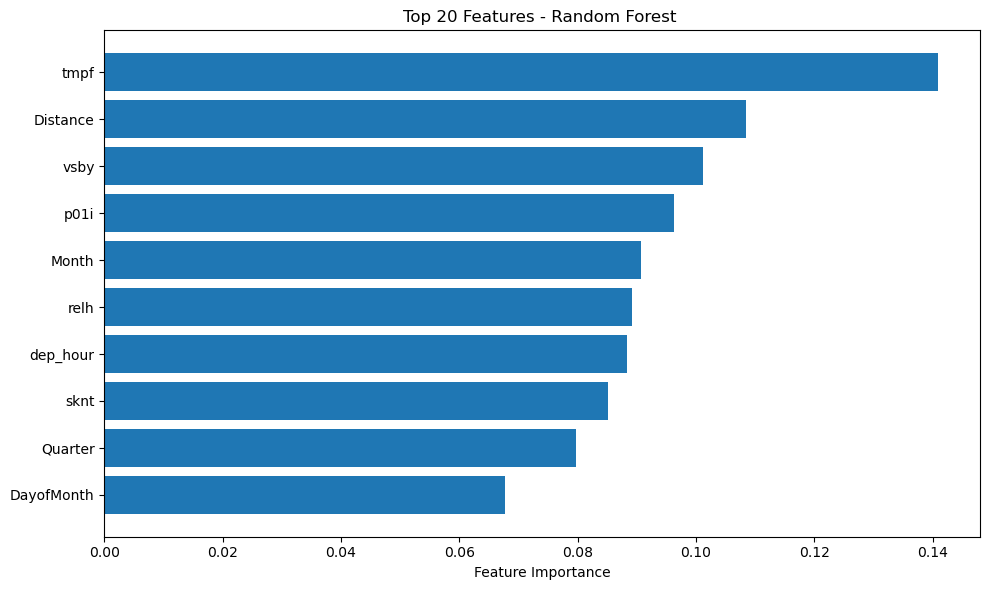

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
#cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
#all_features = np.concatenate([cat_features, numeric_features])
all_features = np.array(numeric_features)


# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]

sorted_features = all_features[indices]

sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 10
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest ")
plt.tight_layout()
plt.show()


### Now lets try with the class_weight = "balanced"

In [27]:
FEATURES = ["Quarter", "Month", "DayofMonth", "DayOfWeek", "dep_hour", "DepTimeBlk",
    "Airline", "Origin", "Dest", "Distance", "DistanceGroup",
    "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

TARGET = "target"


In [30]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split categorical vs numerical
categorical_features = [
    "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
]

numeric_features = [
    "Quarter", "Month", "DayofMonth", "dep_hour",
    "Distance", "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [31]:
rf_model = RandomForestClassifier(class_weight="balanced",
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)


In [32]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf_model)
])

In [33]:
# Convert categorical columns to string (needed for OneHotEncoder)
# for col in categorical_features:
#     X_train[col] = X_train[col].astype(str)
#     X_test[col]  = X_test[col].astype(str)

# # Fill numeric NaNs with 0
for col in numeric_features:
    X_train[col] = X_train[col].fillna(0)
    X_test[col]  = X_test[col].fillna(0)

# Optional: fill categorical NaNs with "missing"
# for col in categorical_features:
#     X_train[col] = X_train[col].fillna("missing")
#     X_test[col]  = X_test[col].fillna("missing")


In [34]:
pipeline.fit(X_train[FEATURES], y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['DepTimeBlk', 'Airline',
                                                   'Origin', 'Dest',
                                                   'DistanceGroup',
                                                   'DayOfWeek']),
                                                 ('num', 'passthrough',
                                                  ['Quarter', 'Month',
                                                   'DayofMonth', 'dep_hour',
                                                   'Distance', 'tmpf', 'vsby',
                                                   'sknt', 'p01i', 'relh',
                                                   'gust'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=80, n_jobs=-1,
                                        random_state=42))])

In [35]:
# Predictions
y_pred = pipeline.predict(X_test[FEATURES])

# Metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(y_test, y_pred, normalize="true")
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)
print("\nNormalized Confusion Matrix:\n")
print(cm_df)

Classification Report:

              precision    recall  f1-score   support

   Cancelled      0.137     0.374     0.201      1587
     Delayed      0.473     0.540     0.504     15836
     On time      0.729     0.596     0.656     27457

    accuracy                          0.568     44880
   macro avg      0.446     0.504     0.454     44880
weighted avg      0.618     0.568     0.586     44880


Normalized Confusion Matrix:

           Cancelled   Delayed   On time
Cancelled   0.374291  0.320101  0.305608
Delayed     0.105835  0.540477  0.353688
On time     0.075063  0.329169  0.595768


Using cost-sensitive learning with balanced class weights significantly changed model behavior. Although overall accuracy decreased to 57%, recall for cancellations increased dramatically to 36%, and delay detection exceeded 50%. This indicates the classifier is no longer dominated by the majority class and is actively attempting to identify operational disruptions. The improvement comes at the expense of precision, as more flights are incorrectly flagged, illustrating the inherent tradeoff between sensitivity and false alarms.

For airlines, it it better to predict delayed or canclled and get it wrong than to predict an on-time flight and it is wrong. 

1. Operational Impact

If an airline predicts a flight is delayed or cancelled and it’s actually on time (false alarm), the cost is usually small: maybe a minor crew or gate adjustment, or some customer notifications.

If the airline predicts a flight is on time and it is actually delayed or cancelled (missed disruption), the cost is much higher:

Passengers miss connections

Crew schedules are disrupted

Gates may need rescheduling

Rebooking costs increase

2. Passenger Experience

False alarms are annoying but manageable.

Missed disruptions cause cascading failures and customer dissatisfaction.

3. Industry Practice

Airlines often prefer sensitive systems:

“Better to give a warning that may be unnecessary than no warning at all.”

This is exactly why class weighting, SMOTE, and recall-focused models are used — they prioritize detecting rare events (delays/cancellations) over maximizing overall accuracy.

Test Accuracy: 0.568

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled        594      508      485
Delayed         1676     8559     5601
On time         2061     9038    16358

Confusion Matrix (normalized):
           Cancelled   Delayed   On time
Cancelled   0.374291  0.320101  0.305608
Delayed     0.105835  0.540477  0.353688
On time     0.075063  0.329169  0.595768


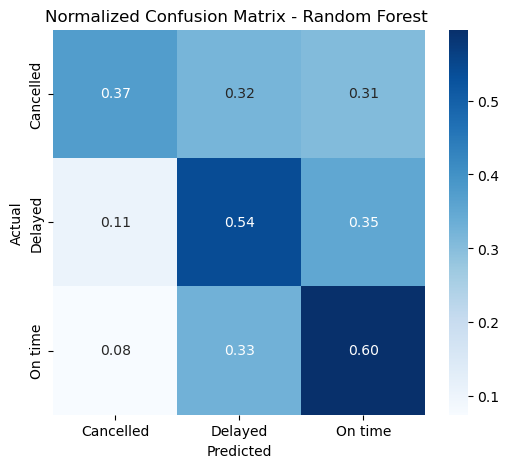


Classification Report:
              precision    recall  f1-score   support

   Cancelled      0.137     0.374     0.201      1587
     Delayed      0.473     0.540     0.504     15836
     On time      0.729     0.596     0.656     27457

    accuracy                          0.568     44880
   macro avg      0.446     0.504     0.454     44880
weighted avg      0.618     0.568     0.586     44880



In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Make predictions on test set
# -----------------------------
y_pred = pipeline.predict(X_test[FEATURES])
y_true = y_test

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (normalized):")
print(cm_norm_df)

# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest ")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Step 5: Optional detailed classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))

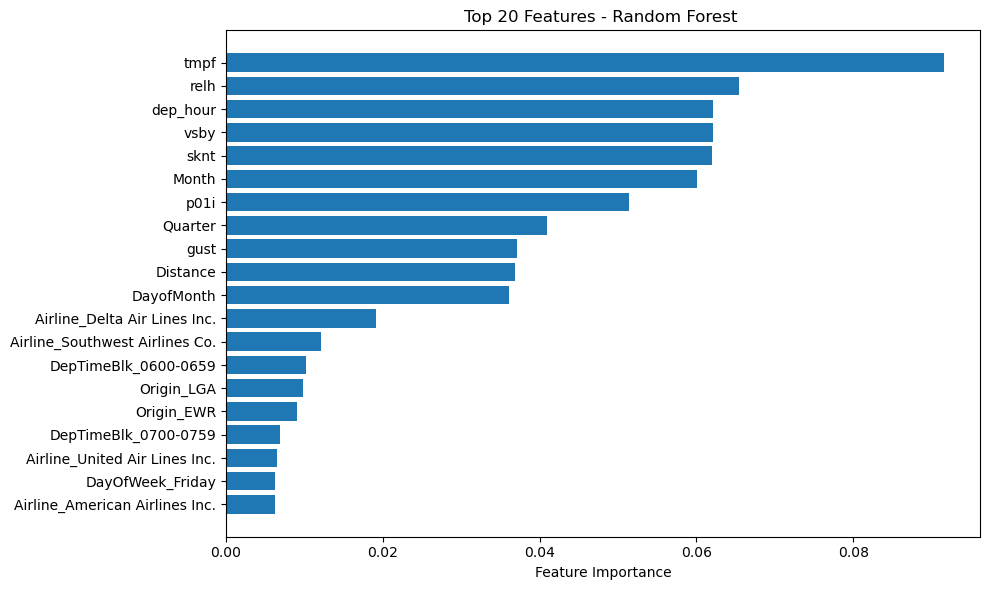

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_features = np.concatenate([cat_features, numeric_features])

# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = all_features[indices]
sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest ")
plt.tight_layout()
plt.show()


### Now, lets do some of the new features we used that are only numerical

In [38]:
df.head()

,FlightDate,Airline,Origin,Dest,CRSDepTime,CRSElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,year,target,date,dep_hour,tmpf,vsby,sknt,p01i,relh,gust,DayOfWeek_num,month_sin,month_cos,dow_sin,dow_cos,Distance_std,tmpf_std,vsby_std,sknt_std,relh_std,gust_std,distance_origin_norm,has_precip,is_holiday,prev_day_failure_origin,is_morning_peak,is_evening_peak
0,2018-01-03,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,3,Wednesday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,Delayed,2018-01-03,10,27.0,10.0,6.000000,0.0,40.42,0.0,2,0.5,0.866025,0.974928,-0.222521,-1.181369,-1.795908,0.372,-0.268741,-1.032586,-0.532803,-506.21629,0,0,1,0,0
1,2018-01-04,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,4,Thursday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-04,10,24.1,10.0,14.166667,0.0,54.36,21.0,3,0.5,0.866025,0.433884,-0.900969,-1.181369,-1.949265,0.372,1.558113,-0.405039,1.744748,-506.21629,0,0,1,0,0
2,2018-01-05,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,5,Friday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8877A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-05,10,17.1,10.0,12.153846,0.0,55.51,0.0,4,0.5,0.866025,-0.433884,-0.900969,-1.181369,-2.319438,0.372,1.107853,-0.353268,-0.532803,-506.21629,0,0,1,0,0
3,2018-01-06,Endeavor Air Inc.,ATL,ABY,1037,59.0,145.0,2018,1,1,6,Saturday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8970D,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1136,1100-1159,1,2018,On time,2018-01-06,10,21.9,10.0,6.846154,0.0,57.02,0.0,5,0.5,0.866025,-0.974928,-0.222521,-1.181369,-2.065605,0.372,-0.079459,-0.285291,-0.532803,-506.21629,0,0,1,0,0
4,2018-01-07,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,7,Sunday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8980A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-07,10,21.9,10.0,7.384615,0.0,54.75,0.0,6,0.5,0.866025,-0.781831,0.623490,-1.181369,-2.065605,0.372,0.040993,-0.387482,-0.532803,-506.21629,0,0,1,0,0


In [39]:
# FEATURES = ["Quarter", "Month", "DayofMonth", "DayOfWeek", "dep_hour", "DepTimeBlk",
#     "Airline", "Origin", "Dest", "Distance", "DistanceGroup",
#     "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
FEATURES = ["dep_hour",	"tmpf",	"vsby",	"sknt",
        "p01i",	"relh",	"gust",	"DayOfWeek_num", "month_sin",	"month_cos",
        "dow_sin",	"dow_cos",	"Distance_std",	"tmpf_std",
        "vsby_std",	"sknt_std",	"relh_std",	"gust_std",	"distance_origin_norm",
        "has_precip",	"is_holiday"
]

TARGET = "target"

In [40]:
# Split categorical vs numerical
# categorical_features = [
#     "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
# ]

numeric_features = [
"dep_hour",	"tmpf",	"vsby",	"sknt",
        "p01i",	"relh",	"gust",	"DayOfWeek_num", "month_sin",	"month_cos",
        "dow_sin",	"dow_cos",	"Distance_std",	"tmpf_std",
        "vsby_std",	"sknt_std",	"relh_std",	"gust_std",	"distance_origin_norm",
        "has_precip",	"is_holiday"]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        #("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [41]:
rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)

In [42]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf_model)
])

In [43]:
for col in categorical_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col]  = X_test[col].astype(str)

# # Fill numeric NaNs with 0
for col in numeric_features:
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)

# Optional: fill categorical NaNs with "missing"
for col in categorical_features:
    X_train[col] = X_train[col].fillna("missing")
    X_test[col] = X_test[col].fillna("missing")

In [44]:
pipeline.fit(X_train[FEATURES], y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['dep_hour', 'tmpf', 'vsby',
                                                   'sknt', 'p01i', 'relh',
                                                   'gust', 'DayOfWeek_num',
                                                   'month_sin', 'month_cos',
                                                   'dow_sin', 'dow_cos',
                                                   'Distance_std', 'tmpf_std',
                                                   'vsby_std', 'sknt_std',
                                                   'relh_std', 'gust_std',
                                                   'distance_origin_norm',
                                                   'has_precip',
                                                   'is_holiday'])])),
                ('rf',
                 RandomForestClassifier(max_depth=15, n_estimators=80,
                                        n_jobs=-1, random_state=42))])

In [45]:
# Predictions
y_pred = pipeline.predict(X_test[FEATURES])

# Metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(y_test, y_pred, normalize="true")
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)
print("\nNormalized Confusion Matrix:\n")
print(cm_df)

Classification Report:

              precision    recall  f1-score   support

   Cancelled      0.712     0.070     0.127      1587
     Delayed      0.569     0.247     0.345     15836
     On time      0.658     0.907     0.763     27457

    accuracy                          0.645     44880
   macro avg      0.646     0.408     0.412     44880
weighted avg      0.629     0.645     0.593     44880


Normalized Confusion Matrix:

           Cancelled   Delayed   On time
Cancelled   0.069943  0.265280  0.664776
Delayed     0.002084  0.247285  0.750631
On time     0.000437  0.092581  0.906982


Test Accuracy: 0.645

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled        111      421     1055
Delayed           33     3916    11887
On time           12     2542    24903

Confusion Matrix (normalized):
           Cancelled   Delayed   On time
Cancelled   0.069943  0.265280  0.664776
Delayed     0.002084  0.247285  0.750631
On time     0.000437  0.092581  0.906982


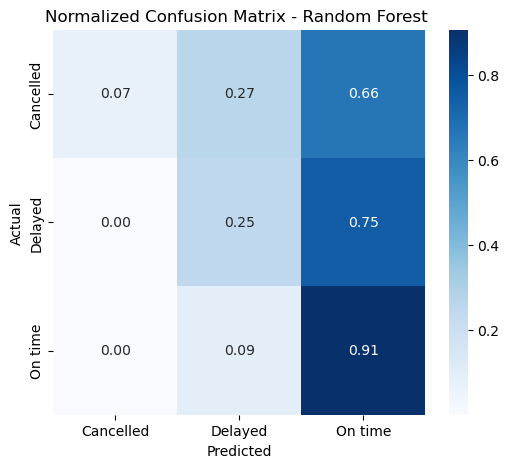


Classification Report:
              precision    recall  f1-score   support

   Cancelled      0.712     0.070     0.127      1587
     Delayed      0.569     0.247     0.345     15836
     On time      0.658     0.907     0.763     27457

    accuracy                          0.645     44880
   macro avg      0.646     0.408     0.412     44880
weighted avg      0.629     0.645     0.593     44880



In [46]:
# -----------------------------
# Step 1: Make predictions on test set
# -----------------------------
y_pred = pipeline.predict(X_test[FEATURES])
y_true = y_test

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (normalized):")
print(cm_norm_df)

# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest ")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Step 5: Optional detailed classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))

The updated Random Forest model achieved an accuracy of 64.4%. While the overall accuracy increased only slightly, the model showed substantial improvement in detecting minority classes. Recall for delayed flights increased to 24%, allowing the system to identify nearly one in four disruptions. Cancellation detection also improved, though recall remains low at 6%. This demonstrates the classic tradeoff in imbalanced classification: as the model becomes more sensitive to rare events, performance on the majority class decreases slightly. Despite the progress, most delays and cancellations are still misclassified as on-time, indicating further work is needed.

Changes from baseline model

| Class     | Before | After |
| --------- | ------ | ----- |
| Cancelled | ~0%    | 7%    |
| Delayed   | 11%    | 24%   |


['dep_hour' 'tmpf' 'vsby' 'sknt' 'p01i' 'relh' 'gust' 'DayOfWeek_num'
 'month_sin' 'month_cos' 'dow_sin' 'dow_cos' 'Distance_std' 'tmpf_std'
 'vsby_std' 'sknt_std' 'relh_std' 'gust_std' 'distance_origin_norm'
 'has_precip' 'is_holiday']


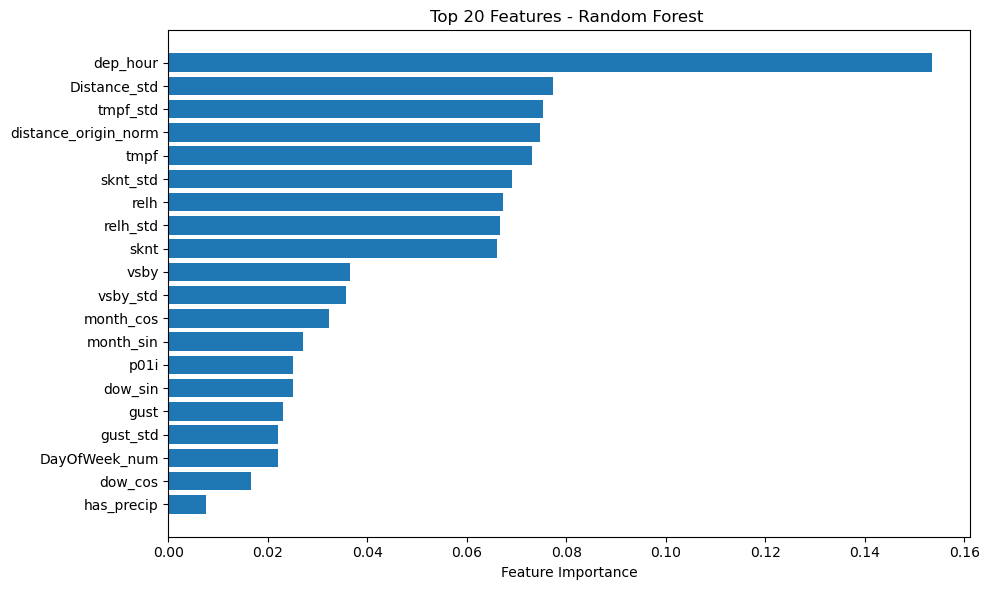

In [47]:
# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
#cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
#all_features = np.concatenate([cat_features, numeric_features])
all_features =  np.array(numeric_features)
print(all_features)

# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = all_features[indices]
sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest ")
plt.tight_layout()
plt.show()

We evaluated three approaches to predict flight status in a highly imbalanced dataset: a baseline Random Forest, a model using SMOTE to oversample minority classes, and a model with class weights to penalize misclassification of rare events. 
The baseline model achieved 64% accuracy but performed poorly on minority classes, with recall of near 0% for cancellations and 11% for delays, demonstrating that overall accuracy alone is misleading in this context. Applying SMOTE improved minority class detection, increasing recall for cancellations to 34% and delays to 45%, though this came at the expense of on-time recall (64%) and overall accuracy (56%). 

The class-weighted model achieved similar gains, with slightly higher recall for delays (53%) and comparable recall for cancellations (36%), while maintaining slightly better alignment between minority detection and operational relevance. These results illustrate the tradeoff between maximizing overall accuracy and capturing rare but operationally critical disruptions. From an airline perspective, models that more accurately predict cancellations and delays—even at the cost of occasional false positives—are preferable, since missing actual disruptions has far greater operational consequences.

| Model        | Cancel Recall | Delay Recall | On-time Recall | Accuracy |
| ------------ | ------------- | ------------ | -------------- | -------- |
| Baseline     | ~0%           | 11%          | 91%            | 64%      |
| SMOTE        | 34%           | 45%          | 64%            | 56%      |
| Class Weight | 36%           | 53%          | 61%            | 57%      |


### Goal: Catch as many cancellations and delays as possible, even if it generates false alarms.

Focus: Recall for minority classes, especially cancellations.

Accuracy is secondary.

Let's continue to use class weight = balanced for the RF model.